<font size=6>实验7：生成对抗网络</font>

# 实验简介

本实验介绍如何利用PyTorch搭建生成对抗网络，并基于MNIST手写数字数据集搭建一个手写数字生成器。通过本实验，你将掌握以下知识和技能：

- 生成对抗网络的基本原理
- 利用PyTorch搭建并训练简单的生成对抗网络
- 组织数据并训练生成对抗网络

# 实验环境准备

首先，你需要安装完成本实验所需的必要组件。

## 安装Miniconda

从以下链接下载Miniconda安装包并完成安装[[Link]](https://mirrors.tuna.tsinghua.edu.cn/anaconda/miniconda/Miniconda3-py310_24.1.2-0-Windows-x86_64.exe)，安装过程中需要选中`Register Anaconda as my default Python 3.10`。若计算机上已经安装好Miniconda或Anaconda，请跳过此步骤。

## 安装必要的Package

在`Anaconda Prompt`中，通过`pip`包管理器安装`Jupyter Notebook`、`PyTorch`、`torchvision`、`matplotlib`包。

```bash
pip install notebook -i https://pypi.tuna.tsinghua.edu.cn/simple/
pip install torch -i https://pypi.tuna.tsinghua.edu.cn/simple/
pip install torchvision -i https://pypi.tuna.tsinghua.edu.cn/simple/
pip install matplotlib -i https://pypi.tuna.tsinghua.edu.cn/simple/
```

当然，可以直接通过以下命令进行全局修改，而不必每次都指定`-i`参数：

```bash
pip config set global.index-url https://pypi.tuna.tsinghua.edu.cn/simple
```

你可以通过执行以下Python代码，检查上述包是否已经安装完成。

In [1]:
import pkgutil

# 检查PyTorch是否已安装
if pkgutil.find_loader('torch'):
    print('PyTorch is available.')

# 检查torchvision是否已安装
if pkgutil.find_loader('torchvision'):
    print('torchvision is available.')

# 检查matplotlib是否已安装
if pkgutil.find_loader('matplotlib'):
    print('matplotlib is available.')

PyTorch is available.
torchvision is available.
matplotlib is available.


# 生成对抗网络基本原理

生成对抗网络（Generative Adversarial Networks, GAN）是一类能够学习训练数据分布，并基于该分布生成新的数据的深度学习模型。模型由一个“生成器”（Generator）和一个“判别器”（Discriminator）组成，其中生成器的任务是基于数据分布生成“伪造”数据，而判别器的任务是对数据进行鉴别，即判断数据是真实样本还是“伪造”出的样本。在训练过程中，生成器不断产生更加逼真的“伪造”数据以欺骗判别器，判别器则不断提高鉴别真伪的能力，以更好地分类真实样本和伪造样本。当生成器能够生成近乎完美的“伪造”样本，使得判别器认为该样本是真实样本和“伪造样本”的置信度相等时，上述博弈达到均衡状态。

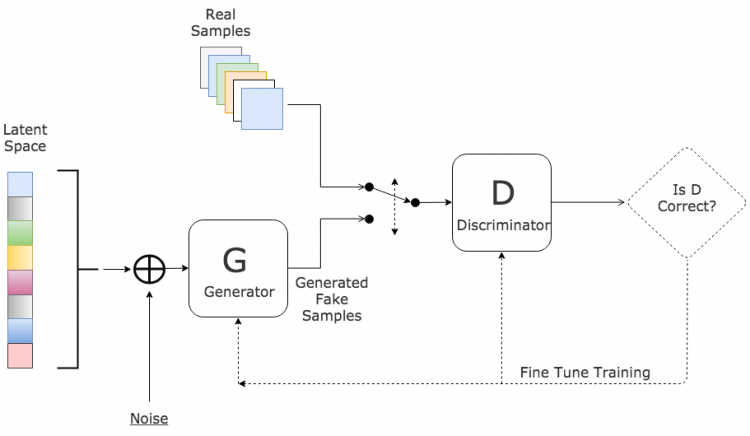

假设 $x$ 代表图像数据，$D(x)$ 是判别器网络，其输出为 $x$ 来自真实训练样本（而非生成器伪造的数据）的概率。显然，当 $x$ 来自训练数据时，$D(x)$ 的输出结果较大；而当 $x$ 是生成器伪造的数据时，$D(x)$ 的输出值较小。同时，假设 $z$ 为从标准正态分布中采样的潜空间向量（Latent space vector），$G(z)$ 表示生成器，它将潜向量 $z$ 映射到数据空间。$G$ 的目标是估计训练数据的分布 ($p_{data}$)，以便基于该分布生成伪造样本（$p_g$）。

进一步地，$D(G(z))$ 表示生成器 $G$ 的输出是真实图像的概率。$D$ 和 $G$ 形成Minimax博弈，$D$ 试图最大化其正确分类真假图像的概率（$logD(x)$），而 $G$ 试图最小化 $D$ 预测其输出为假的概率（$log(1-D(x)$）。生成对抗网络的损失函数为：

$$\underset{G}{\text{min}} \underset{D}{\text{max}}V(D,G) = \mathbb{E}_{x\sim p_{data}(x)}\big[logD(x)\big] + \mathbb{E}_{z\sim p_{z}(z)}\big[log(1-D(G(z)))\big]$$

生成对抗网络首先由Ian Goodfellow于2014年提出（[Generative Adversarial Nets](https://papers.nips.cc/paper/5423-generative-adversarial-nets.pdf)）。

# 数据加载和查看

在本实验中，我们使用MNIST手写数字数据集，训练一个可以生成逼真的手写数字图片的生成对抗网络模型。

首先，加载必要的包。

In [2]:
import os
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

定义超参数，并判断是否存在可用的GPU设备。

In [3]:
# 定义优化器及模型训练超参数
LR = .0002
BETA1 = .5
EPOCHS = 1
BATCH_SIZE = 128

# 判断是否存在可用的GPU设备
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

下载MNIST数据，并对数据进行变换（transform）。当执行`torchvision.datasets.MNIST`方法时，将判断指定目录下是否已存在完整的MNIST数据集。若不存在，将自动下载MNIST数据集。

In [4]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.,), (1.,))]
)

try:
    trainset = torchvision.datasets.MNIST('./data', transform=transform)
except RuntimeError:
    trainset = torchvision.datasets.MNIST('./data', download=True, transform=transform)

Using downloaded and verified file: ./data\MNIST\raw\train-images-idx3-ubyte.gz
Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Using downloaded and verified file: ./data\MNIST\raw\train-labels-idx1-ubyte.gz
Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Using downloaded and verified file: ./data\MNIST\raw\t10k-images-idx3-ubyte.gz
Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Using downloaded and verified file: ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz
Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



数据准备完成后，可查看数据集的部分样本。

In [5]:
def plot_digits(dataset):
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=10, shuffle=True)
    trainiter = iter(trainloader)
    batch = trainiter.__next__()

    fig = plt.figure(figsize=(20,200))
    for j in range(10):
        plt.subplot(1,10,j+1)
        plt.imshow(batch[0][j][0,:], cmap='gray')
        plt.title(batch[1][j].item())
        plt.axis('off')

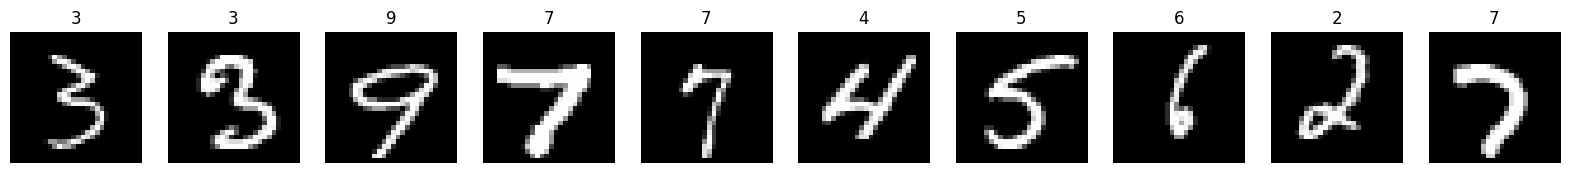

In [6]:
plot_digits(trainset)

# 模型定义

## 定义生成器和判别器

首先，定义生成器和判别器。生成器和判别器是各自独立的神经网络，其中：

- 生成器的输出为28×28的矩阵（即“伪造”的手写数字图片）；
- 判别器的输出是图片是否为真的概率。

这里为简便起见，生成器和判别器均使用全连接神经网络。

In [7]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.lin1 = nn.Linear(100, 256)
        self.lin2 = nn.Linear(256, 512)
        self.lin3 = nn.Linear(512, 1024)
        self.lin4 = nn.Linear(1024, 784)
        self.leaky_relu = nn.LeakyReLU(.2)

    def forward(self, input):
        x = self.leaky_relu(self.lin1(input))
        x = self.leaky_relu(self.lin2(x))
        x = self.leaky_relu(self.lin3(x))
        x = self.leaky_relu(self.lin4(x))
        return torch.tanh(x).view(-1, 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.lin1 = nn.Linear(784, 1024)
        self.lin2 = nn.Linear(1024, 512)
        self.lin3 = nn.Linear(512, 256)
        self.lin4 = nn.Linear(256, 1)
        self.leaky_relu = nn.LeakyReLU(.2)
        self.dropout = nn.Dropout(.3)

    def forward(self, input):
        x = input.view(-1, 784)
        x = self.leaky_relu(self.lin1(x))
        x = self.dropout(x)
        x = self.leaky_relu(self.lin2(x))
        x = self.dropout(x)
        x = self.leaky_relu(self.lin3(x))
        x = self.dropout(x)
        x = self.leaky_relu(self.lin4(x))
        return torch.sigmoid(x)

## 定义生成对抗网络模型

接下来，定义一个`GAN`类，用于定义生成对抗网络的模型结构和训练过程。

In [13]:
class GAN():
    def __init__(self, generator, discriminator, loss, optimizerG, optimizerD, batch_size=BATCH_SIZE):
        self.generator = generator
        self.discriminator = discriminator
        self.loss = loss
        self.optimG = optimizerG
        self.optimD = optimizerD
        self.batch_size = batch_size

    def generate_fake(self, batch):
        return self.generator(batch)

    def plot_ten_samples(self):
        noise = torch.randn(10, 100, device=device)
        fake = self.generate_fake(noise).cpu()
        fake = fake.detach().numpy()
        fig = plt.figure(figsize=(20, 200))
        for j in range(10):
            plt.subplot(1, 10, j + 1)
            plt.imshow(fake[j][0], cmap='gray')
            plt.axis('off')
        plt.show()

    def train(self, trainset, epochs=EPOCHS, verbose=True):
        trainloader = torch.utils.data.DataLoader(trainset, batch_size=self.batch_size, shuffle=True)
        errG_history = []
        errD_history = []
        try:
            for epoch in range(epochs):
                if epoch % 10 == 0:
                    self.plot_ten_samples()
                epoch_gerr = []
                epoch_derr = []
                for j, data in enumerate(trainloader, 0):
                    
                    # 训练判别器
                    self.optimD.zero_grad()
                    
                    # 使用真实样本进行训练
                    real = data[0].to(device)
                    batch_size = real.size()[0]
                    real_labels = torch.ones(batch_size, 1, device=device) * .9
                    out = self.discriminator(real)
                    errD_real = self.loss(out, real_labels)
                    errD_real.backward()
                    
                    # 使用伪造样本进行训练
                    noise = torch.randn(batch_size, 100, device=device)
                    fake = self.generate_fake(noise)
                    fake_labels = torch.ones(batch_size, 1, device=device) * .1
                    out = self.discriminator(fake)
                    errD_fake = self.loss(out, fake_labels)
                    errD_fake.backward()
                    self.optimD.step()
                    epoch_derr += [(errD_real.item() + errD_fake.item()) * .5]
                    
                    # 训练生成器
                    self.optimG.zero_grad()
                    noise = torch.randn(batch_size, 100, device=device)
                    fake = self.generate_fake(noise)
                    fake_labels = torch.ones(batch_size, 1, device=device)
                    out = self.discriminator(fake)
                    errG = self.loss(out, fake_labels)
                    errG.backward()
                    self.optimG.step()
                    epoch_gerr += [errG.item()]

                errD_history += [torch.tensor(epoch_derr).mean()]
                errG_history += [torch.tensor(epoch_gerr).mean()]

                print(f'EPOCH {epoch + 1:2}/{epochs}')
                print(f"disc_loss: {errD_history[-1]:.4f} - gen_loss: {errG_history[-1]:.4f}")
                
        except KeyboardInterrupt:
            return errG_history, errD_history

        return errG_history, errD_history

实例化生成器和判别器。

In [14]:
dnet = Discriminator().to(device)
gnet = Generator().to(device)

指定模型的损失函数、优化器，并实例化生成对抗网络模型。

In [15]:
loss = nn.BCELoss()
optimizerD = torch.optim.Adam(dnet.parameters(), lr=LR, betas=(BETA1, 0.999))
optimizerG = torch.optim.Adam(gnet.parameters(), lr=LR, betas=(BETA1, 0.999))

gan = GAN(gnet, dnet, loss, optimizerG, optimizerD)

# 模型训练

调用`gan`对象的`train`方法，以完成模型训练。

训练刚刚开始时，产生的样本是完全随机的噪声；随着训练epoch数的增多，生成的手写数字图像越来越接近真实样本。

此处可按需设置`epochs`，一般而言，至少需要训练20个epoch才能生成较为真实的图像。当使用CPU进行训练时，完成1个epoch的训练大约耗时30秒。

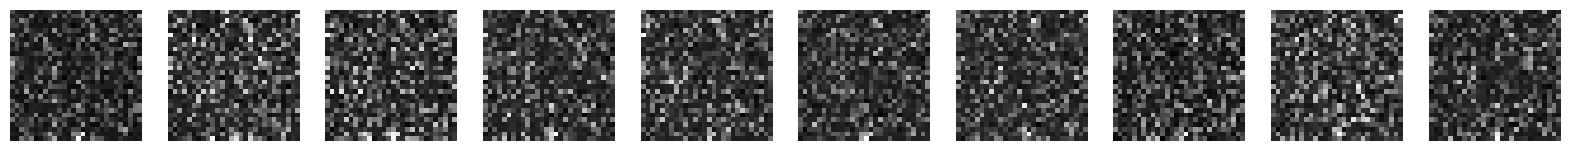

EPOCH  1/30
disc_loss: 0.5488 - gen_loss: 1.1277
EPOCH  2/30
disc_loss: 0.4942 - gen_loss: 1.9338
EPOCH  3/30
disc_loss: 0.4843 - gen_loss: 2.1155
EPOCH  4/30
disc_loss: 0.4804 - gen_loss: 2.0583
EPOCH  5/30
disc_loss: 0.4767 - gen_loss: 2.0524
EPOCH  6/30
disc_loss: 0.4658 - gen_loss: 1.9946
EPOCH  7/30
disc_loss: 0.4706 - gen_loss: 1.9093
EPOCH  8/30
disc_loss: 0.4674 - gen_loss: 1.8807
EPOCH  9/30
disc_loss: 0.4657 - gen_loss: 1.8392
EPOCH 10/30
disc_loss: 0.4777 - gen_loss: 1.7631


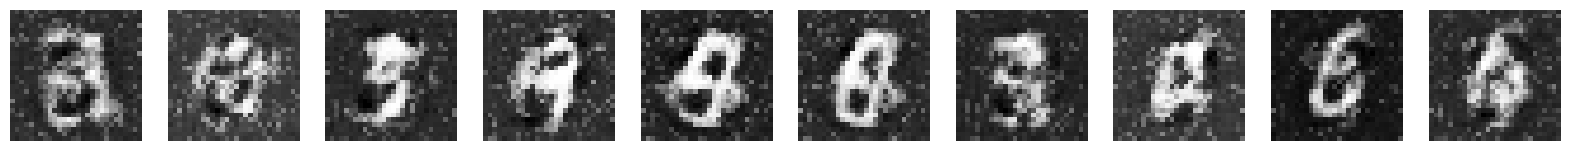

EPOCH 11/30
disc_loss: 0.4962 - gen_loss: 1.6578
EPOCH 12/30
disc_loss: 0.5079 - gen_loss: 1.5823
EPOCH 13/30
disc_loss: 0.5146 - gen_loss: 1.5400
EPOCH 14/30
disc_loss: 0.5225 - gen_loss: 1.4917
EPOCH 15/30
disc_loss: 0.5231 - gen_loss: 1.4743
EPOCH 16/30
disc_loss: 0.5266 - gen_loss: 1.4476
EPOCH 17/30
disc_loss: 0.5266 - gen_loss: 1.4356
EPOCH 18/30
disc_loss: 0.5240 - gen_loss: 1.4524
EPOCH 19/30
disc_loss: 0.5249 - gen_loss: 1.4486
EPOCH 20/30
disc_loss: 0.5199 - gen_loss: 1.4595


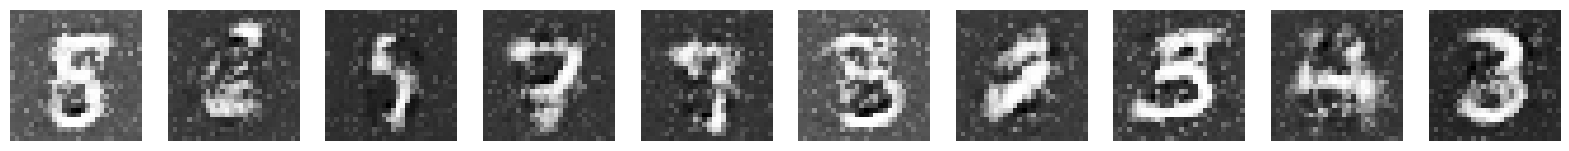

EPOCH 21/30
disc_loss: 0.5149 - gen_loss: 1.4698
EPOCH 22/30
disc_loss: 0.5135 - gen_loss: 1.4748
EPOCH 23/30
disc_loss: 0.5085 - gen_loss: 1.5045
EPOCH 24/30
disc_loss: 0.5049 - gen_loss: 1.5212
EPOCH 25/30
disc_loss: 0.5030 - gen_loss: 1.5239
EPOCH 26/30
disc_loss: 0.4966 - gen_loss: 1.5359
EPOCH 27/30
disc_loss: 0.4945 - gen_loss: 1.5686
EPOCH 28/30
disc_loss: 0.4917 - gen_loss: 1.5686
EPOCH 29/30
disc_loss: 0.4887 - gen_loss: 1.5829
EPOCH 30/30
disc_loss: 0.4860 - gen_loss: 1.6053


In [16]:
errorG_history, errorD_history = gan.train(trainset, epochs=30)

模型训练结束后，可通过调用以下方法，随机生成10张“伪造”图片，以检验模型的生成效果。

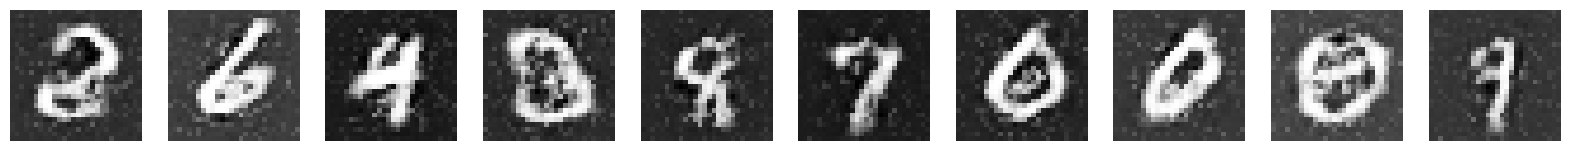

In [17]:
gan.plot_ten_samples()

通过执行以下代码块，可查看训练过程中生成器、判别器损失函数值的变化情况。

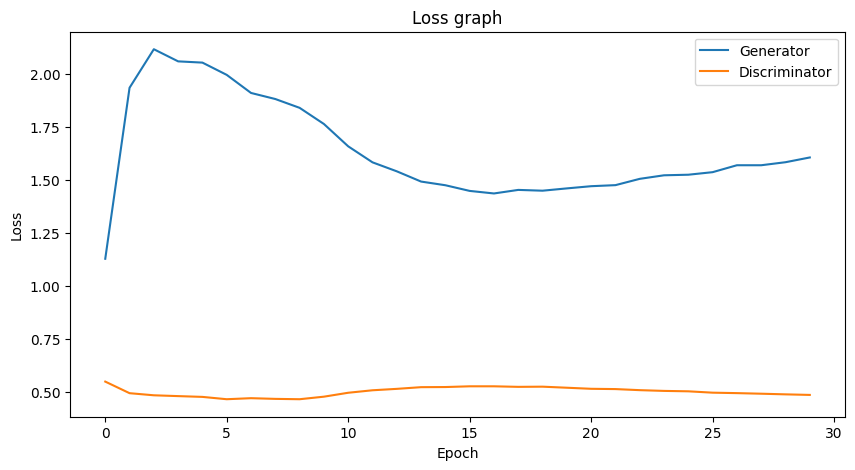

In [18]:
plt.figure(figsize=(10,5))
plt.plot(errorG_history)
plt.plot(errorD_history)
plt.title('Loss graph')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Generator','Discriminator'])